In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import sys
import argparse
from pathlib import Path

import pandas as pd
import torch

PROJECT_ROOT = Path("/vol/biomedic3/tx1215/mamo-flow")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_handle.embed import (
    get_embed,
    DatasetConfig,
)

from sample_flow import (
    build_flow_model_from_ckpt_args,
    maybe_apply_ema,
)

In [2]:
CKPT_PATH = Path(
    "/vol/biomedic3/tx1215/mamo-flow/checkpoints/"
    "embed_flow_gpus48_128_96_condemb_per_attr_mchannel_32_puncond_0.2/"
    "last_checkpoint.pt"
)

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

ckpt = torch.load(CKPT_PATH, map_location="cpu")
train_args = argparse.Namespace(**ckpt["args"])

datasets = get_embed(
    DatasetConfig(
        data_dir=train_args.data_dir,
        split_dir=train_args.split_dir,
        cache_dir=getattr(train_args, "cache_dir", None),
        parents=train_args.parents,
        img_height=train_args.img_height,
        img_width=train_args.img_width,
        img_channels=train_args.img_channels,
        vae_ckpt=getattr(train_args, "vae_ckpt", None),
    )
)

print("Parents:", train_args.parents)
print("Splits:", datasets.keys())

Parents: ['age', 'view', 'density', 'scanner', 'cview']
Splits: dict_keys(['train', 'valid', 'test'])


In [3]:
PAIR_CSV = (
    Path(train_args.split_dir)
    / "EMBED_same_breast_CC_MLO_pairs.csv"
)

pairs_df = pd.read_csv(PAIR_CSV)

SOURCE_VIEW = "CC"       # "CC" or "MLO"
TARGET_VIEW = "MLO" if SOURCE_VIEW == "CC" else "CC"

print("Pairs:", len(pairs_df))
print(f"{SOURCE_VIEW} -> {TARGET_VIEW}")

pairs_df.head()

Pairs: 81581
CC -> MLO


,split,empi_anon,acc_anon,laterality,cc_path,mlo_path,cc_cache_idx,mlo_cache_idx,cc_empi_anon,mlo_empi_anon,...,cc_cview,mlo_cview,cc_age,mlo_age,cc_split,mlo_split,cc_ViewPosition_norm,mlo_ViewPosition_norm,cc_Laterality_norm,mlo_Laterality_norm
0,test,10000879,6992096043050201,L,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,14592,14590,10000879,10000879,...,0,0,41.879026,41.879026,test,test,CC,MLO,L,L
1,test,10000879,6992096043050201,R,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,14591,14589,10000879,10000879,...,0,0,41.879026,41.879026,test,test,CC,MLO,R,R
2,test,10015693,1334581155737139,L,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,8940,8939,10015693,10015693,...,0,0,65.167663,65.167663,test,test,CC,MLO,L,L
3,test,10015693,1334581155737139,R,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,8938,8937,10015693,10015693,...,0,0,65.167663,65.167663,test,test,CC,MLO,R,R
4,test,10015693,2281263876413228,L,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,14550,14549,10015693,10015693,...,0,0,67.407271,67.407271,test,test,CC,MLO,L,L


In [4]:
idx = 0
row = pairs_df.iloc[idx]

split = row["split"]

cc_sample = datasets[split][
    int(row["cc_cache_idx"])
]

mlo_sample = datasets[split][
    int(row["mlo_cache_idx"])
]

if SOURCE_VIEW == "CC":
    source_sample = cc_sample
    gt_sample = mlo_sample
else:
    source_sample = mlo_sample
    gt_sample = cc_sample

print("Split:", split)
print("CC:", cc_sample["shortpath"])
print("MLO:", mlo_sample["shortpath"])

Split: test
CC: cohort_1/10000879/1.2.842.113970.3.62.1.56868341.20180426.1095160/1.2.849.113681.2750825173.1524118968.4850.25068/1.2.826.0.1.3680043.8.498.95624330443091298195832829311598612912.png
MLO: cohort_1/10000879/1.2.842.113970.3.62.1.56868341.20180426.1095160/1.2.842.113684.2750825173.1524118966.4849.25082/1.2.826.0.1.3680043.8.498.28558322321478064615270687074132715555.png


In [5]:
def prepare_x(sample):
    x = sample["x"].unsqueeze(0).float().to(DEVICE)

    # Same logic as flow sampling:
    # image mode [0,1] -> [-1,1]
    if x.shape[1] <= 3:
        x = x * 2.0 - 1.0

    return x


x_src = prepare_x(source_sample)
x_gt = prepare_x(gt_sample)

pa_src = {
    k: v.unsqueeze(0).to(DEVICE)
    for k, v in source_sample["pa"].items()
}

print("x_src:", x_src.shape)
print("x_gt :", x_gt.shape)

print("\nSource conditioning:")
for k, v in pa_src.items():
    print(k, v)

x_src: torch.Size([1, 1, 128, 96])
x_gt : torch.Size([1, 1, 128, 96])

Source conditioning:
age tensor([[0.4188]], device='cuda:0')
view tensor([[0., 1.]], device='cuda:0')
density tensor([[0., 0., 1., 0.]], device='cuda:0')
scanner tensor([[1., 0., 0., 0., 0.]], device='cuda:0')
cview tensor([[1., 0.]], device='cuda:0')


In [6]:
pa_cf = {
    k: v.clone()
    for k, v in pa_src.items()
}

# view is one-hot:
# MLO = class 0
# CC  = class 1

source_idx = pa_src["view"].argmax(dim=-1)
target_idx = 1 - source_idx

pa_cf["view"].zero_()
pa_cf["view"].scatter_(
    -1,
    target_idx.unsqueeze(-1),
    1.0,
)

print("Source view:", pa_src["view"])
print("CF view:    ", pa_cf["view"])
print(f"{SOURCE_VIEW} -> {TARGET_VIEW}")

Source view: tensor([[0., 1.]], device='cuda:0')
CF view:     tensor([[1., 0.]], device='cuda:0')
CC -> MLO


In [7]:
def build_time_grid(direction, device, ode_steps=None):
    if ode_steps is None:
        if direction == "backward":
            return torch.tensor([1.0, 0.0], device=device)
        else:
            return torch.tensor([0.0, 1.0], device=device)

    if direction == "backward":
        return torch.linspace(1.0, 0.0, ode_steps + 1, device=device)
    else:
        return torch.linspace(0.0, 1.0, ode_steps + 1, device=device)

def invert_to_noise(
    model,
    x,
    pa_src,
    ode_method="dopri5",
    ode_atol=1e-5,
    ode_rtol=1e-5,
    ode_steps=None,
):
    t = build_time_grid(
        "backward",
        x.device,
        ode_steps,
    )

    traj = model.ode_solve(
        x,
        pa=pa_src,
        t=t,
        method=ode_method,
        atol=ode_atol,
        rtol=ode_rtol,
    )

    return traj[-1]

def generate_from_noise(
    model,
    noise,
    pa_cf,
    ode_method="dopri5",
    ode_atol=1e-5,
    ode_rtol=1e-5,
    ode_steps=None,
):
    t = build_time_grid(
        "forward",
        noise.device,
        ode_steps,
    )

    traj = model.ode_solve(
        noise,
        pa=pa_cf,
        t=t,
        method=ode_method,
        atol=ode_atol,
        rtol=ode_rtol,
    )

    return traj[-1]

In [8]:
# Load trained flow model
model = build_flow_model_from_ckpt_args(
    train_args=train_args,
    device=DEVICE,
)

model.load_state_dict(
    ckpt["model_state_dict"],
    strict=True,
)

maybe_apply_ema(
    model=model,
    ckpt=ckpt,
    ema_rate=getattr(train_args, "ema_rate", 0.9999),
    use_ema=True,
)

model.eval()

print("Model loaded.")

Creating embedder for parent 'age' with input dim 1 and output dim 32
Creating embedder for parent 'view' with input dim 2 and output dim 32
Creating embedder for parent 'density' with input dim 4 and output dim 32
Creating embedder for parent 'scanner' with input dim 5 and output dim 32
Creating embedder for parent 'cview' with input dim 2 and output dim 32
Model loaded.


In [9]:
with torch.no_grad():

    # 1. Source image -> latent/noise
    z = invert_to_noise(
        model=model,
        x=x_src,
        pa_src=pa_src,
    )

    # 2. Same latent, but flip view condition
    x_cf = generate_from_noise(
        model=model,
        noise=z,
        pa_cf=pa_cf,
    )

print("Source:", x_src.shape)
print("Latent :", z.shape)
print("CF     :", x_cf.shape)
print("GT     :", x_gt.shape)

Source: torch.Size([1, 1, 128, 96])
Latent : torch.Size([1, 1, 128, 96])
CF     : torch.Size([1, 1, 128, 96])
GT     : torch.Size([1, 1, 128, 96])


In [10]:
with torch.no_grad():

    x_recon = generate_from_noise(
        model=model,
        noise=z,
        pa_cf=pa_src,   # unchanged conditioning
    )

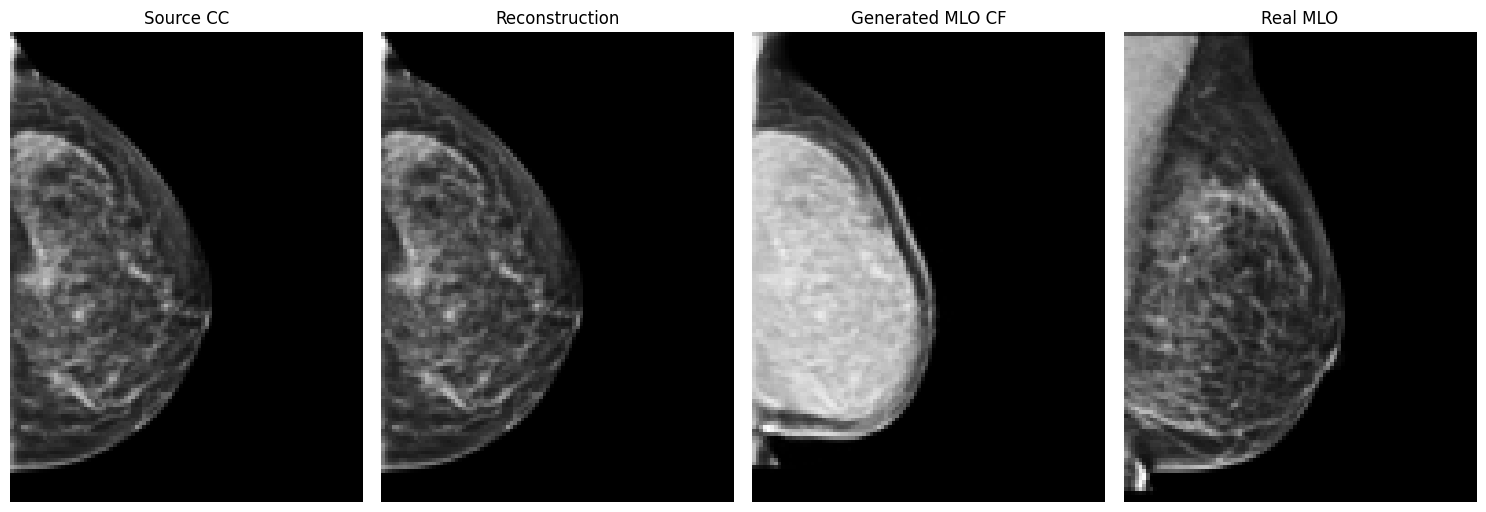

In [11]:
%matplotlib inline

def show_x(x):
    x = x.detach().cpu().float()
    x = (x.clamp(-1, 1) + 1.0) / 2.0

    return x[0, 0].numpy()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(15, 5),
)

axes[0].imshow(show_x(x_src), cmap="gray")
axes[0].set_title(f"Source {SOURCE_VIEW}")

axes[1].imshow(show_x(x_recon), cmap="gray")
axes[1].set_title("Reconstruction")

axes[2].imshow(show_x(x_cf), cmap="gray")
axes[2].set_title(f"Generated {TARGET_VIEW} CF")

axes[3].imshow(show_x(x_gt), cmap="gray")
axes[3].set_title(f"Real {TARGET_VIEW}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()